<a href="https://colab.research.google.com/github/EEHZYDHAVE/behavioural-credit-signals-for-fintech/blob/main/Expanding_Access_to_Credit_Invisible_Segment__Installment_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Expanding Access to "Credit Invisible" Segments**
# **Phase Do Behavioral Payment Signals Predict NPL Better Than Demographics?**

---

### The Big Picture

Part 1 established that traditional demographic proxies are weak predictors of NPL
outcomes. The best single variable scored **0.0801**. Even when demographics were
combined into borrower profiles, 80% of the riskiest group still repaid, meaning
demographics cannot draw a precise enough line for individual credit decisions.

Part 2 now asks a different question entirely: what if instead of looking at
**who someone is**, we look at **how they actually behave** when repaying a loan?


### The Critical Difference

Demographics are **static**, they describe a borrower at the moment of application
and do not change. Payment behavior is **dynamic**, it is a record of actual
financial decisions made over time, capturing whether a borrower's habits are
consistent, deteriorating, or improving.

These are fundamentally different types of information. Part 2 is testing whether
the dynamic type is more informative than the static type when predicting who
will default.



### The Data Source

`installments_payments.csv` contains the repayment history for previous loans taken
by borrowers in our dataset. Every installment record captures:

- When the payment was **due**
- When it was **actually made**
- How much was **owed**
- How much was **actually paid**

From this raw data we engineer behavioral signals that describe how a borrower
actually behaves with money, not just what demographic box they fit into.



### Our Approach, Option A: Overlapping Population

Not every borrower in our dataset has installment records. Some had no prior loans
with Home Credit and therefore no repayment history to draw from.

We deliberately choose to work only with borrowers who have installment records.
This means:

- The behavioral signal evaluation runs on this subset only
- The demographic signal evaluation is re-run on the **same subset** for comparison
- We are comparing demographics vs behavior within the exact same population
- The comparison is apples to apples, same borrowers, same TARGET variable,
same signal strength scale

> **The one downside:** we are not covering the full 307,511 borrowers, only
> those with prior repayment history. However, if the overlap turns out to be
> large, this is a win for the analysis. We will investigate the size of this
> overlap as our first step and report it transparently.



### The Dual Benchmark Part 2 Must Beat

From Part 1, behavioral signals need to surpass two specific bars:

| Benchmark | Value | What It Means |
|---|---|---|
| Individual signal ceiling | 0.0801 | Best single demographic variable score |
| Combined profile ceiling | 80% repayment in riskiest group | Demographics cannot separate individuals even when combined |

If behavioral signals score above **0.0801** individually, they outperform the
best traditional proxy. If behavioral profiles draw a sharper line at the
individual level than combined demographics could, the case for alternative
data is made.

---

### What Comes Next

We now load `installments_payments.csv`, investigate the overlapping population,
engineer behavioral features, and run the same signal evaluation framework used
in Part 1. The comparison will be direct, deliberate, and evidence-backed.

## **1 Importing the Necessary Librabry**

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
# Download the dataset

dataset_url = 'https://www.kaggle.com/competitions/home-credit-default-risk/data'

%time
od.download(dataset_url)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.39 µs
Skipping, found downloaded files in "./home-credit-default-risk" (use force=True to force download)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

### **1.1 loading the Dataset**

In [ ]:
data_dir = 'home-credit-default-risk'
!ls -lh {data_dir}

total 2.5G
-rw-r--r-- 1 root root  26M Mar  4 00:30 application_test.csv
-rw-r--r-- 1 root root 159M Mar  4 00:30 application_train.csv
-rw-r--r-- 1 root root 359M Mar  4 00:30 bureau_balance.csv
-rw-r--r-- 1 root root 163M Mar  4 00:30 bureau.csv
-rw-r--r-- 1 root root 405M Mar  4 00:30 credit_card_balance.csv
-rw-r--r-- 1 root root  37K Mar  4 00:30 HomeCredit_columns_description.csv
-rw-r--r-- 1 root root 690M Mar  4 00:30 installments_payments.csv
-rw-r--r-- 1 root root 375M Mar  4 00:30 POS_CASH_balance.csv
-rw-r--r-- 1 root root 387M Mar  4 00:31 previous_application.csv
-rw-r--r-- 1 root root 524K Mar  4 00:31 sample_submission.csv


## **Data Cleaning**

Cleaning the `application_train.csv` file

In [ ]:
# ============================================================
# DATA CLEANING
# ============================================================

# --- application_train.csv ---

# load application data
app = pd.read_csv(f'{data_dir}/application_train.csv')

# 1. Convert DAYS_BIRTH from negative days to age in years
app['AGE'] = (app['DAYS_BIRTH'].abs() / 365).astype(int)

# 2. Convert DAYS_EMPLOYED to positive — negative means currently employed
#    365243 is a placeholder value used for pensioners/unemployed, replace with 0
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, 0)
app['EMPLOYMENT_YEARS'] = (app['DAYS_EMPLOYED'].abs() / 365).round(1)

# 3. Fill OCCUPATION_TYPE missing values with 'Unknown'
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].fillna('Unknown')

# 4. Drop building/property features — not demographic proxies, out of scope
property_cols = [col for col in app.columns if any(x in col for x in [
    'APARTMENTS', 'BASEMENTAREA', 'YEARS_BUILD', 'COMMONAREA',
    'ELEVATORS', 'ENTRANCES', 'FLOORSMAX', 'FLOORSMIN', 'LANDAREA',
    'LIVINGAPARTMENTS', 'LIVINGAREA', 'NONLIVINGAPARTMENTS', 'NONLIVINGAREA',
    'TOTALAREA', 'WALLSMATERIAL', 'EMERGENCYSTATE', 'FONDKAPREMONT',
    'HOUSETYPE', 'YEARS_BEGINEXPLUATATION'
])]
app = app.drop(columns=property_cols)

# 5. Drop EXT_SOURCE columns — external credit score proxies, not demographics
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
app = app.drop(columns=ext_cols, errors='ignore')

# 6. Drop AMT_REQ_CREDIT_BUREAU columns — these reference bureau activity
bureau_req_cols = [col for col in app.columns if 'AMT_REQ_CREDIT_BUREAU' in col]
app = app.drop(columns=bureau_req_cols)

# Confirm result
print(f"application_train shape after cleaning: {app.shape}")
print(f"Remaining columns: {app.shape[1]}")
print(f"\nRemaining missing values:")
remaining_missing = app.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(remaining_missing if not remaining_missing.empty else "None")

application_train shape after cleaning: (307511, 68)
Remaining columns: 68

Remaining missing values:
AMT_ANNUITY                     12
AMT_GOODS_PRICE                278
NAME_TYPE_SUITE               1292
OWN_CAR_AGE                 202929
CNT_FAM_MEMBERS                  2
OBS_30_CNT_SOCIAL_CIRCLE      1021
DEF_30_CNT_SOCIAL_CIRCLE      1021
OBS_60_CNT_SOCIAL_CIRCLE      1021
DEF_60_CNT_SOCIAL_CIRCLE      1021
DAYS_LAST_PHONE_CHANGE           1
dtype: int64


In [ ]:
# ============================================================
# SELECT CORE COLUMNS ONLY
# ============================================================

core_columns = [
    # Identifier and outcome
    'SK_ID_CURR', 'TARGET',

    # Pure demographics
    'AGE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_INCOME_TYPE', 'AMT_INCOME_TOTAL',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',

    # Loan request characteristics
    'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',

    # Soft stability signals
    'EMPLOYMENT_YEARS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE',
    'REGION_RATING_CLIENT', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
]

# Keep only core columns
app = app[core_columns]

# Check shape and missing values
print(f"Dataset shape after column selection: {app.shape}")
print(f"\nMissing values per column:")
missing = app.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else "No missing values")

# Quick overview of the dataset
print(f"\nData types:")
print(app.dtypes)

Dataset shape after column selection: (307511, 26)

Missing values per column:
CNT_FAM_MEMBERS      2
AMT_ANNUITY         12
AMT_GOODS_PRICE    278
dtype: int64

Data types:
SK_ID_CURR                   int64
TARGET                       int64
AGE                          int64
CODE_GENDER                 object
NAME_EDUCATION_TYPE         object
NAME_FAMILY_STATUS          object
CNT_CHILDREN                 int64
CNT_FAM_MEMBERS            float64
NAME_INCOME_TYPE            object
AMT_INCOME_TOTAL           float64
OCCUPATION_TYPE             object
ORGANIZATION_TYPE           object
NAME_CONTRACT_TYPE          object
AMT_CREDIT                 float64
AMT_ANNUITY                float64
AMT_GOODS_PRICE            float64
EMPLOYMENT_YEARS           float64
FLAG_OWN_CAR                object
FLAG_OWN_REALTY             object
NAME_HOUSING_TYPE           object
REGION_RATING_CLIENT         int64
DAYS_REGISTRATION          float64
DAYS_ID_PUBLISH              int64
REG_CITY_NOT_LIVE_CIT

## **1 Exploratory Data Analsis**

Investigating the population to be used in the analysis

=== INSTALLMENTS DATA OVERVIEW ===

Shape: 13,605,401 rows x 8 columns
Duplicate rows: 0

Columns: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']

Missing values:
DAYS_ENTRY_PAYMENT    2905
AMT_PAYMENT           2905
dtype: int64

Data types:
SK_ID_PREV                  int64
SK_ID_CURR                  int64
NUM_INSTALMENT_VERSION    float64
NUM_INSTALMENT_NUMBER       int64
DAYS_INSTALMENT           float64
DAYS_ENTRY_PAYMENT        float64
AMT_INSTALMENT            float64
AMT_PAYMENT               float64
dtype: object

=== POPULATION OVERLAP INVESTIGATION ===

Total borrowers in application_train:     307,511
Borrowers WITH installment records:        291,643 (94.8%)
Borrowers WITHOUT installment records:     15,868 (5.2%)

=== NPL RATE COMPARISON ===

NPL rate — borrowers WITH instalment records:     8.19%
NPL rate — borrowers WITHOUT instalment records:  5.98%
NPL rate — fu

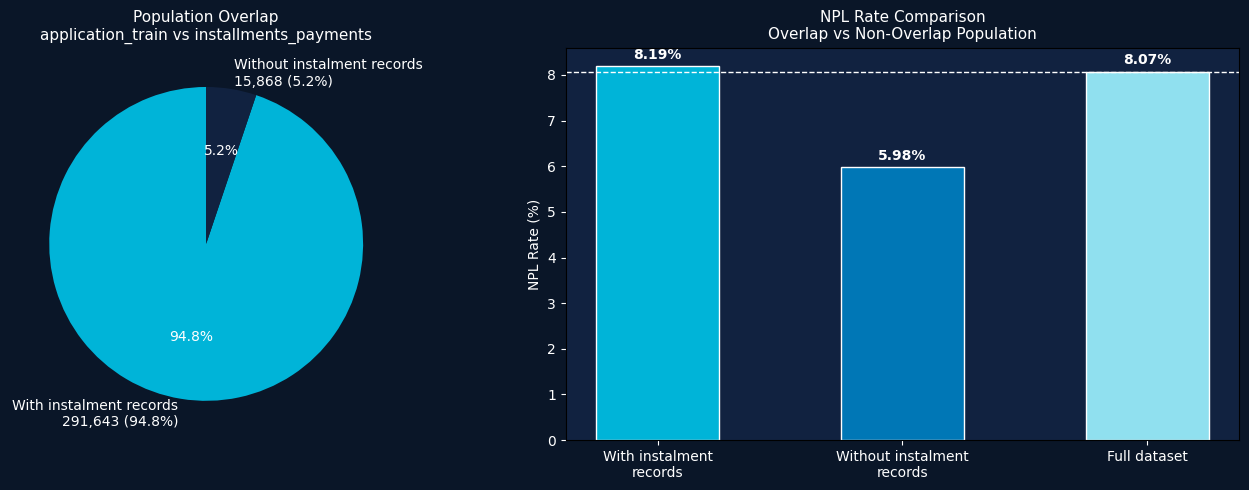


=== WORKING POPULATION LOCKED ===
Borrowers in Part 2 analysis:  291,643
Installment records available: 11,591,592
NPL rate in working population: 8.19%


In [ ]:
# ============================================================
# STAGE 1: LOAD INSTALLMENTS DATA & POPULATION AUDIT
# ============================================================

# Load installments data
inst = pd.read_csv(f'{data_dir}/installments_payments.csv')

# ============================================================
# BASIC DIAGNOSTIC
# ============================================================
print("=== INSTALLMENTS DATA OVERVIEW ===\n")
print(f"Shape: {inst.shape[0]:,} rows x {inst.shape[1]} columns")
print(f"Duplicate rows: {inst.duplicated().sum()}")
print(f"\nColumns: {list(inst.columns)}")

print(f"\nMissing values:")
missing = inst.isnull().sum()
missing = missing[missing > 0]
print(missing if not missing.empty else "None")

print(f"\nData types:")
print(inst.dtypes)

# ============================================================
# POPULATION OVERLAP INVESTIGATION
# ============================================================
print("\n=== POPULATION OVERLAP INVESTIGATION ===\n")

# Unique borrowers in installments data
inst_borrowers = set(inst['SK_ID_CURR'].unique())

# Unique borrowers in main dataset
app_borrowers = set(app['SK_ID_CURR'].unique())

# Overlap
overlap = inst_borrowers.intersection(app_borrowers)
no_inst_record = app_borrowers - inst_borrowers

print(f"Total borrowers in application_train:     {len(app_borrowers):,}")
print(f"Borrowers WITH installment records:        {len(overlap):,} ({len(overlap)/len(app_borrowers)*100:.1f}%)")
print(f"Borrowers WITHOUT installment records:     {len(no_inst_record):,} ({len(no_inst_record)/len(app_borrowers)*100:.1f}%)")

# ============================================================
# NPL RATE COMPARISON — OVERLAP VS NON-OVERLAP
# ============================================================
print("\n=== NPL RATE COMPARISON ===\n")

app_overlap = app[app['SK_ID_CURR'].isin(overlap)]
app_no_overlap = app[~app['SK_ID_CURR'].isin(overlap)]

print(f"NPL rate — borrowers WITH instalment records:     {app_overlap['TARGET'].mean()*100:.2f}%")
print(f"NPL rate — borrowers WITHOUT instalment records:  {app_no_overlap['TARGET'].mean()*100:.2f}%")
print(f"NPL rate — full dataset:                          {app['TARGET'].mean()*100:.2f}%")

# ============================================================
# INSTALLMENTS PER BORROWER
# ============================================================
print("\n=== INSTALLMENT RECORDS PER BORROWER ===\n")

inst_per_borrower = inst.groupby('SK_ID_CURR').size()
print(f"Average installments per borrower:   {inst_per_borrower.mean():.1f}")
print(f"Median installments per borrower:    {inst_per_borrower.median():.1f}")
print(f"Min installments per borrower:       {inst_per_borrower.min()}")
print(f"Max installments per borrower:       {inst_per_borrower.max():,}")

# ============================================================
# VISUAL — POPULATION OVERLAP PIE CHART
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — overlap
sizes = [len(overlap), len(no_inst_record)]
labels = [f'With instalment records\n{len(overlap):,} ({len(overlap)/len(app_borrowers)*100:.1f}%)',
          f'Without instalment records\n{len(no_inst_record):,} ({len(no_inst_record)/len(app_borrowers)*100:.1f}%)']
colors = ['#00B4D8', '#112240']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'color': 'white', 'fontsize': 10})
axes[0].set_title('Population Overlap\napplication_train vs installments_payments',
                  color='white', fontsize=11)
axes[0].set_facecolor('#0A1628')
fig.patch.set_facecolor('#0A1628')

# Bar chart — NPL rate comparison
groups = ['With instalment\nrecords', 'Without instalment\nrecords', 'Full dataset']
npl_rates = [
    app_overlap['TARGET'].mean()*100,
    app_no_overlap['TARGET'].mean()*100,
    app['TARGET'].mean()*100
]
bars = axes[1].bar(groups, npl_rates, color=['#00B4D8', '#0077B6', '#90E0EF'],
                   edgecolor='white', width=0.5)
axes[1].axhline(y=app['TARGET'].mean()*100, color='white',
                linestyle='--', linewidth=1, label='Overall NPL rate')
axes[1].set_title('NPL Rate Comparison\nOverlap vs Non-Overlap Population',
                  color='white', fontsize=11)
axes[1].set_ylabel('NPL Rate (%)', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#112240')
for bar, val in zip(bars, npl_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# LOCK THE WORKING POPULATION
# ============================================================
app_part2 = app[app['SK_ID_CURR'].isin(overlap)].copy()
inst_part2 = inst[inst['SK_ID_CURR'].isin(overlap)].copy()

print(f"\n=== WORKING POPULATION LOCKED ===")
print(f"Borrowers in Part 2 analysis:  {len(app_part2):,}")
print(f"Installment records available: {len(inst_part2):,}")
print(f"NPL rate in working population: {app_part2['TARGET'].mean()*100:.2f}%")

## **1.1 Findings: Population Overlap & Data Overview**

#### The Overlap Result, A Win for the Analysis

Of the 307,511 borrowers in our dataset, **291,643 (94.8%)** have prior installment
records. Only **15,868 borrowers (5.2%)** have no repayment history and are excluded
from Part 2.

This means our behavioral analysis covers almost the entire dataset, the concern
about losing too many borrowers by working only with the overlapping population
turns out to be negligible.

| Population | Borrowers | NPL Rate |
|---|---|---|
| With installment records | 291,643 (94.8%) | 8.19% |
| Without installment records | 15,868 (5.2%) | 5.98% |
| Full dataset | 307,511 | 8.07% |

The NPL rate in our working population (8.19%) is almost identical to the full
dataset (8.07%), confirming the subset is not systematically biased. The
comparison between demographics and behavioral signals will be honest and
representative.

#### Installments Data Overview

- **13.6 million** installment records across 291,643 borrowers
- **Average of 40 installments per borrower**, enough repayment history to
build meaningful behavioral signals
- **Missing values:** only 2,905 rows out of 13.6 million, effectively clean
- The key columns available are payment due date, actual payment date, amount
owed, and amount actually paid, exactly what we need for behavioral feature
engineering

#### What Comes Next

With the working population locked at 291,643 borrowers and rich repayment
history confirmed, we move into Stage 2, engineering behavioral features
from the raw installment records.

## **2 Behavioral Feature Engineering**

#### What We Are Doing
Raw installment records tell us when payments were due and when they were made.
But a single row of payment data means nothing on its own, what matters is the
pattern across all of a borrower's payments. We now transform those 13.6 million
raw records into borrower-level behavioral signals.

#### The Features We Are Engineering

Every feature is derived from the gap between what was scheduled and what actually
happened, in timing and in amount.

**Payment Delay Signals**: how late a borrower pays, how often, and how severe
their worst delays are. This captures payment timing behavior directly.

**Payment Amount Signals**: whether a borrower pays the full amount owed, how
often they underpay, and the ratio of what they paid versus what was due. This
captures financial commitment behavior.

**Payment Consistency Signals**: whether a borrower's behavior is stable or
erratic over time, and whether their delays are getting worse or improving. This
captures behavioral trajectory.

**Payment Trend Signal**: whether delays are increasing or decreasing over the
course of the loan. A borrower whose delays are getting worse is fundamentally
different from one whose behavior is improving.

#### Why These Features Matter
Demographics tell us who a borrower is. These features tell us what a borrower
actually does when faced with a repayment obligation. That difference is exactly
what Phase 2 is testing.

In [ ]:
# ============================================================
# STAGE 2: BEHAVIORAL FEATURE ENGINEERING
# ============================================================

# Work with the overlapping population only
inst_p2 = inst_part2.copy()

# ============================================================
# STEP 1 CALCULATE PAYMENT DELAY
# Positive value = paid late, Negative = paid early, 0 = on time
# Missing DAYS_ENTRY_PAYMENT means payment was not made, treat as max delay
# ============================================================

# Fill missing payment dates with the due date + 90 days (severe delay proxy)
inst_p2['DAYS_ENTRY_PAYMENT'] = inst_p2['DAYS_ENTRY_PAYMENT'].fillna(
    inst_p2['DAYS_INSTALMENT'] + 90
)
inst_p2['AMT_PAYMENT'] = inst_p2['AMT_PAYMENT'].fillna(0)

# Calculate delay in days (positive = late)
inst_p2['PAYMENT_DELAY'] = inst_p2['DAYS_ENTRY_PAYMENT'] - inst_p2['DAYS_INSTALMENT']

# Calculate payment ratio (how much of what was owed was actually paid)
inst_p2['PAYMENT_RATIO'] = inst_p2['AMT_PAYMENT'] / (inst_p2['AMT_INSTALMENT'] + 1e-9)

# Flag for underpayment (paid less than 95% of what was owed)
inst_p2['UNDERPAID'] = (inst_p2['PAYMENT_RATIO'] < 0.95).astype(int)

# Flag for late payment (paid more than 1 day late)
inst_p2['PAID_LATE'] = (inst_p2['PAYMENT_DELAY'] > 1).astype(int)

print("Base calculations complete.")
print(f"Average payment delay across all records: {inst_p2['PAYMENT_DELAY'].mean():.2f} days")
print(f"% of payments made late: {inst_p2['PAID_LATE'].mean()*100:.2f}%")
print(f"% of payments underpaid: {inst_p2['UNDERPAID'].mean()*100:.2f}%")

# ============================================================
# STEP 2 PAYMENT TREND
# Is the borrower's delay getting worse or better over time?
# We measure this by correlating installment number with delay
# Positive correlation = delays getting worse over time
# Negative correlation = delays improving over time
# ============================================================

def compute_delay_trend(group):
    if len(group) < 3:
        return 0
    correlation = group['NUM_INSTALMENT_NUMBER'].corr(group['PAYMENT_DELAY'])
    return correlation if not np.isnan(correlation) else 0

print("\nComputing payment delay trend per borrower (this may take a moment)...")
delay_trend = inst_p2.groupby('SK_ID_CURR').apply(
    compute_delay_trend, include_groups=False
).reset_index()
delay_trend.columns = ['SK_ID_CURR', 'DELAY_TREND']
print("Delay trend computed.")

# ============================================================
# STEP 3 AGGREGATE TO BORROWER LEVEL
# ============================================================
print("\nAggregating to borrower level...")

behavioral_features = inst_p2.groupby('SK_ID_CURR').agg(
    # Payment delay signals
    AVG_PAYMENT_DELAY      = ('PAYMENT_DELAY', 'mean'),
    MAX_PAYMENT_DELAY      = ('PAYMENT_DELAY', 'max'),
    STD_PAYMENT_DELAY      = ('PAYMENT_DELAY', 'std'),
    LATE_PAYMENT_RATE      = ('PAID_LATE', 'mean'),
    TOTAL_LATE_PAYMENTS    = ('PAID_LATE', 'sum'),

    # Payment amount signals
    AVG_PAYMENT_RATIO      = ('PAYMENT_RATIO', 'mean'),
    MIN_PAYMENT_RATIO      = ('PAYMENT_RATIO', 'min'),
    UNDERPAYMENT_RATE      = ('UNDERPAID', 'mean'),
    TOTAL_UNDERPAYMENTS    = ('UNDERPAID', 'sum'),

    # Payment consistency signals
    NUM_INSTALLMENTS       = ('PAYMENT_DELAY', 'count'),

).reset_index()

# Merge delay trend
behavioral_features = behavioral_features.merge(delay_trend, on='SK_ID_CURR', how='left')

print(f"\nBehavioral features engineered: {behavioral_features.shape[1] - 1} features")
print(f"Borrowers covered: {len(behavioral_features):,}")
print(f"\nFeature summary:")
print(behavioral_features.describe().round(3).to_string())

Base calculations complete.
Average payment delay across all records: -8.74 days
% of payments made late: 6.63%
% of payments underpaid: 6.81%

Computing payment delay trend per borrower (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Delay trend computed.

Aggregating to borrower level...

Behavioral features engineered: 11 features
Borrowers covered: 291,643

Feature summary:
       SK_ID_CURR  AVG_PAYMENT_DELAY  MAX_PAYMENT_DELAY  STD_PAYMENT_DELAY  LATE_PAYMENT_RATE  TOTAL_LATE_PAYMENTS  AVG_PAYMENT_RATIO  MIN_PAYMENT_RATIO  UNDERPAYMENT_RATE  TOTAL_UNDERPAYMENTS  NUM_INSTALLMENTS  DELAY_TREND
count  291643.000         291643.000         291643.000         290951.000         291643.000           291643.000       2.916430e+05       2.916430e+05         291643.000           291643.000        291643.000   291643.000
mean   278218.606            -11.182             16.469             12.671              0.058                2.633       5.755521e+08       1.344276e+08              0.058                2.706            39.746        0.137
std    102836.512             13.170            111.170             24.831              0.099                5.345       1.389020e+11       7.220141e+10              0.106           

In [ ]:
# ============================================================
# STAGE 2 FIX CAP PAYMENT RATIO OUTLIERS
# ============================================================

# The raw payment ratio has extreme outliers caused by near-zero
# installment amounts. We cap at 2.0, anything above means the
# borrower overpaid significantly which is not meaningful for our analysis

inst_p2['PAYMENT_RATIO'] = inst_p2['PAYMENT_RATIO'].clip(upper=2.0)

# Re-aggregate with capped ratio
behavioral_features = inst_p2.groupby('SK_ID_CURR').agg(
    # Payment delay signals
    AVG_PAYMENT_DELAY      = ('PAYMENT_DELAY', 'mean'),
    MAX_PAYMENT_DELAY      = ('PAYMENT_DELAY', 'max'),
    STD_PAYMENT_DELAY      = ('PAYMENT_DELAY', 'std'),
    LATE_PAYMENT_RATE      = ('PAID_LATE', 'mean'),
    TOTAL_LATE_PAYMENTS    = ('PAID_LATE', 'sum'),

    # Payment amount signals
    AVG_PAYMENT_RATIO      = ('PAYMENT_RATIO', 'mean'),
    MIN_PAYMENT_RATIO      = ('PAYMENT_RATIO', 'min'),
    UNDERPAYMENT_RATE      = ('UNDERPAID', 'mean'),
    TOTAL_UNDERPAYMENTS    = ('UNDERPAID', 'sum'),

    # Payment consistency signals
    NUM_INSTALLMENTS       = ('PAYMENT_DELAY', 'count'),

).reset_index()

# Merge delay trend back in
behavioral_features = behavioral_features.merge(delay_trend, on='SK_ID_CURR', how='left')

# ============================================================
# CONFIRM FIX
# ============================================================
print("=== BEHAVIORAL FEATURES — AFTER FIX ===\n")
print(f"Behavioral features engineered: {behavioral_features.shape[1] - 1} features")
print(f"Borrowers covered: {len(behavioral_features):,}")

print(f"\nPayment ratio range check:")
print(f"AVG_PAYMENT_RATIO — min: {behavioral_features['AVG_PAYMENT_RATIO'].min():.4f}, max: {behavioral_features['AVG_PAYMENT_RATIO'].max():.4f}, mean: {behavioral_features['AVG_PAYMENT_RATIO'].mean():.4f}")
print(f"MIN_PAYMENT_RATIO — min: {behavioral_features['MIN_PAYMENT_RATIO'].min():.4f}, max: {behavioral_features['MIN_PAYMENT_RATIO'].max():.4f}, mean: {behavioral_features['MIN_PAYMENT_RATIO'].mean():.4f}")

print(f"\nDelay range check:")
print(f"AVG_PAYMENT_DELAY — min: {behavioral_features['AVG_PAYMENT_DELAY'].min():.2f}, max: {behavioral_features['AVG_PAYMENT_DELAY'].max():.2f}, mean: {behavioral_features['AVG_PAYMENT_DELAY'].mean():.2f}")
print(f"MAX_PAYMENT_DELAY — min: {behavioral_features['MAX_PAYMENT_DELAY'].min():.2f}, max: {behavioral_features['MAX_PAYMENT_DELAY'].max():.2f}, mean: {behavioral_features['MAX_PAYMENT_DELAY'].mean():.2f}")

print(f"\nFull feature summary:")
print(behavioral_features.describe().round(4).to_string())

=== BEHAVIORAL FEATURES — AFTER FIX ===

Behavioral features engineered: 11 features
Borrowers covered: 291,643

Payment ratio range check:
AVG_PAYMENT_RATIO — min: 0.0000, max: 2.0000, mean: 0.9688
MIN_PAYMENT_RATIO — min: 0.0000, max: 2.0000, mean: 0.5949

Delay range check:
AVG_PAYMENT_DELAY — min: -295.00, max: 1884.20, mean: -11.18
MAX_PAYMENT_DELAY — min: -156.00, max: 2884.00, mean: 16.47

Full feature summary:
        SK_ID_CURR  AVG_PAYMENT_DELAY  MAX_PAYMENT_DELAY  STD_PAYMENT_DELAY  LATE_PAYMENT_RATE  TOTAL_LATE_PAYMENTS  AVG_PAYMENT_RATIO  MIN_PAYMENT_RATIO  UNDERPAYMENT_RATE  TOTAL_UNDERPAYMENTS  NUM_INSTALLMENTS  DELAY_TREND
count  291643.0000        291643.0000        291643.0000        290951.0000        291643.0000          291643.0000        291643.0000        291643.0000        291643.0000          291643.0000       291643.0000  291643.0000
mean   278218.6065           -11.1823            16.4691            12.6711             0.0582               2.6332             

### **2.1 Findings: Behavioral Feature Engineering**

From 13.6 million raw installment records across 291,643 borrowers, we engineered
**11 borrower-level behavioral features** grouped into three signal types:

**Payment Delay Signals**: average delay, maximum delay, delay variability,
late payment rate, and total late payments. These capture how consistently and
promptly a borrower meets payment deadlines.

**Payment Amount Signals**: average payment ratio, minimum payment ratio,
underpayment rate, and total underpayments. These capture whether a borrower
pays what they owe or consistently falls short.

**Payment Consistency Signal**: delay trend, measuring whether a borrower's
payment behavior is improving or deteriorating over time.

#### Key Observations from the Raw Features

- The average borrower pays **11 days early**: the population is broadly
responsible with payment timing
- Only **6.63% of payments** were made late across the entire dataset
- Only **6.81% of payments** were underpaid
- The median borrower has **zero late payments and zero underpayments**:
meaning more than half the population has a clean repayment record
- Extreme outliers exist: maximum delay of 2,884 days, representing a small
group of severely distressed borrowers. These are genuine data points and are
retained in the analysis.

> **One fix applied:** Payment ratios were capped at 2.0 to remove arithmetic
> artifacts caused by near-zero installment amounts. This brings the average
> payment ratio to a sensible **0.9688**, meaning the average borrower pays
> approximately 97% of what they owe.

## **3 Merging Behavioral Features with Main Dataset**

#### What We Are Doing
The 11 behavioral features are now at the borrower level, one row per borrower
summarising their full repayment history. We merge these onto our Part 2 working
population so that each borrower has both their demographic profile and their
behavioral signal profile alongside the TARGET outcome variable.

This merged dataset is the foundation for the signal evaluation in Stage 4.
Having both feature types on the same rows for the same borrowers is what makes
the Part 1 vs Part 2 comparison direct and apples to apples.

> **Note:** 692 borrowers had a null standard deviation for payment delay, this
> occurs when a borrower has only one installment record, making standard deviation
> undefined. These were filled with 0 before merging, which is the correct
> treatment, a borrower with one payment has no variability by definition.

In [ ]:
# ============================================================
# STAGE 3 MERGE BEHAVIORAL FEATURES WITH MAIN DATASET
# ============================================================

# Fill null STD_PAYMENT_DELAY borrowers with only one installment record
behavioral_features['STD_PAYMENT_DELAY'] = behavioral_features[
    'STD_PAYMENT_DELAY'].fillna(0)

# Merge behavioral features onto the Part 2 working population
app_part2 = app_part2.merge(behavioral_features, on='SK_ID_CURR', how='left')

# ============================================================
# CONFIRMATION CHECK
# ============================================================
print("=== MERGE CONFIRMATION ===\n")
print(f"Working dataset shape: {app_part2.shape}")
print(f"Borrowers: {len(app_part2):,}")
print(f"Total features: {app_part2.shape[1]}")

print(f"\nMissing values in behavioral features:")
behavioral_cols = [
    'AVG_PAYMENT_DELAY', 'MAX_PAYMENT_DELAY', 'STD_PAYMENT_DELAY',
    'LATE_PAYMENT_RATE', 'TOTAL_LATE_PAYMENTS', 'AVG_PAYMENT_RATIO',
    'MIN_PAYMENT_RATIO', 'UNDERPAYMENT_RATE', 'TOTAL_UNDERPAYMENTS',
    'NUM_INSTALLMENTS', 'DELAY_TREND'
]

# Debugging: Print columns of app_part2 to see what's actually there
print("Columns in app_part2 right before checking behavioral features:")
print(app_part2.columns.tolist())

missing_check = app_part2[behavioral_cols].isnull().sum()
print(missing_check if missing_check.sum() > 0 else "None — all behavioral features complete")

print(f"\nNPL rate in merged dataset: {app_part2['TARGET'].mean()*100:.2f}%")
print(f"\nSample of merged dataset:")
print(app_part2[['SK_ID_CURR', 'TARGET', 'AGE', 'CODE_GENDER',
                   'AVG_PAYMENT_DELAY', 'LATE_PAYMENT_RATE',
                   'AVG_PAYMENT_RATIO', 'DELAY_TREND']].head(10).to_string(index=False))

=== MERGE CONFIRMATION ===

Working dataset shape: (291643, 37)
Borrowers: 291,643
Total features: 37

Missing values in behavioral features:
Columns in app_part2 right before checking behavioral features:
['SK_ID_CURR', 'TARGET', 'AGE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_INCOME_TYPE', 'AMT_INCOME_TOTAL', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'EMPLOYMENT_YEARS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE', 'REGION_RATING_CLIENT', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'AVG_PAYMENT_DELAY', 'MAX_PAYMENT_DELAY', 'STD_PAYMENT_DELAY', 'LATE_PAYMENT_RATE', 'TOTAL_LATE_PAYMENTS', 'AVG_PAYMENT_RATIO', 'MIN_PAYMENT_RATIO', 'UNDERPAYMENT_RATE', 'TOTAL_UNDERPAYMENTS', 'NUM_INSTALLMENTS', 'DELAY_TREND']
None — all behavioral features complete

NPL rate in merged dataset: 8

## **3.1 Confirmed: Clean Merged Dataset**

The working dataset for Part 2 is now confirmed and locked:

| | |
|---|---|
| **Borrowers** | 291,643 |
| **Total features** | 37 (26 demographic + 11 behavioral) |
| **Missing values** | 0 |
| **NPL rate** | 8.19% |

The 26 demographic columns from Part 1 and the 11 engineered behavioral
features are now on the same rows for the same borrowers. This is the
foundation for the direct comparison in Stage 4,  same population, same
TARGET variable, same signal strength scale. The only thing changing is
the type of data being tested.

## **4 Behavioral Signal Evaluation**

#### What We Are Doing
We now run the exact same signal evaluation framework used in Part 1 on our
11 behavioral features. For each feature we measure how strongly it associates
with NPL outcomes using the same statistical tools and the same signal strength
scale.

This is what makes the comparison honest, identical methodology, identical
population, identical outcome variable. The only thing changing is the type
of data being tested: behavioral signals instead of demographic proxies.

#### The Benchmark We Are Testing Against
From Part 1, the dual baseline behavioral signals must beat is:

- **Individual ceiling:** 0.0801, the strongest any single demographic
variable performed
- **Collective ceiling:** even combined demographics left 80% of the riskiest
group repaying, demographics cannot draw a precise individual line

If any behavioral signal scores above **0.0801**, it outperforms the best
traditional demographic proxy. If behavioral signals collectively produce
stronger separation than demographics could, the case for alternative data
is made.

#### The 11 Behavioral Features Being Tested

| Feature | What It Measures |
|---|---|
| AVG_PAYMENT_DELAY | Average days late across all payments |
| MAX_PAYMENT_DELAY | Worst single payment delay |
| STD_PAYMENT_DELAY | Consistency of payment timing |
| LATE_PAYMENT_RATE | Proportion of payments made late |
| TOTAL_LATE_PAYMENTS | Raw count of late payments |
| AVG_PAYMENT_RATIO | Average proportion of amount paid vs owed |
| MIN_PAYMENT_RATIO | Worst single payment amount ratio |
| UNDERPAYMENT_RATE | Proportion of payments where amount fell short |
| TOTAL_UNDERPAYMENTS | Raw count of underpayments |
| NUM_INSTALLMENTS | Total number of installment records |
| DELAY_TREND | Whether delays are getting worse or improving over time |

=== BEHAVIORAL SIGNAL RANKING ===

           Variable       Type  Signal Score Direction  P-Value Significant
  LATE_PAYMENT_RATE Behavioral        0.0713  Positive 0.000000         Yes
  UNDERPAYMENT_RATE Behavioral        0.0667  Positive 0.000000         Yes
  AVG_PAYMENT_RATIO Behavioral        0.0658  Negative 0.000000         Yes
  MIN_PAYMENT_RATIO Behavioral        0.0460  Negative 0.000000         Yes
TOTAL_LATE_PAYMENTS Behavioral        0.0333  Positive 0.000000         Yes
TOTAL_UNDERPAYMENTS Behavioral        0.0309  Positive 0.000000         Yes
  AVG_PAYMENT_DELAY Behavioral        0.0215  Positive 0.000000         Yes
   NUM_INSTALLMENTS Behavioral        0.0211  Negative 0.000000         Yes
        DELAY_TREND Behavioral        0.0154  Positive 0.000000         Yes
  MAX_PAYMENT_DELAY Behavioral        0.0054  Positive 0.003732         Yes
  STD_PAYMENT_DELAY Behavioral        0.0048  Positive 0.009208         Yes

=== COMPARISON AGAINST PART 1 BASELINE ===

Part 1 d

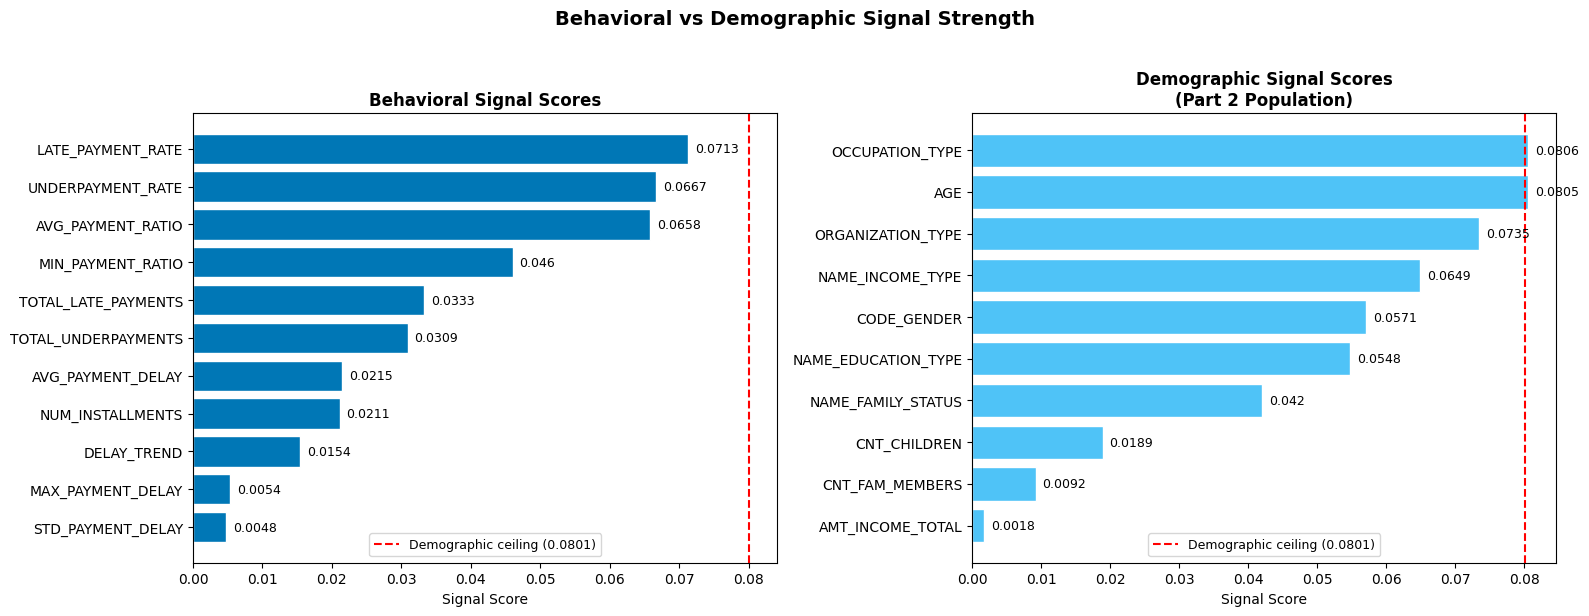

In [ ]:
# ============================================================
# STAGE 4: BEHAVIORAL SIGNAL EVALUATION
# ============================================================

from scipy import stats
import numpy as np

behavioral_cols = [
    'AVG_PAYMENT_DELAY', 'MAX_PAYMENT_DELAY', 'STD_PAYMENT_DELAY',
    'LATE_PAYMENT_RATE', 'TOTAL_LATE_PAYMENTS', 'AVG_PAYMENT_RATIO',
    'MIN_PAYMENT_RATIO', 'UNDERPAYMENT_RATE', 'TOTAL_UNDERPAYMENTS',
    'NUM_INSTALLMENTS', 'DELAY_TREND'
]

# ============================================================
# SIGNAL EVALUATION POINT BISERIAL CORRELATION
# All behavioral features are continuous so we use the same
# test we used for continuous demographics in Part 1
# ============================================================

behavioral_results = []

for col in behavioral_cols:
    corr, p_value = stats.pointbiserialr(
        app_part2['TARGET'], app_part2[col]
    )
    behavioral_results.append({
        'Variable': col,
        'Type': 'Behavioral',
        'Signal Score': round(abs(corr), 4),
        'Direction': 'Positive' if corr > 0 else 'Negative',
        'P-Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

behavioral_results_df = pd.DataFrame(behavioral_results).sort_values(
    'Signal Score', ascending=False
)

# ============================================================
# RESULTS TABLE
# ============================================================
print("=== BEHAVIORAL SIGNAL RANKING ===\n")
print(behavioral_results_df.to_string(index=False))

# ============================================================
# COMPARISON AGAINST PART 1 DEMOGRAPHIC CEILING
# ============================================================
print("\n=== COMPARISON AGAINST PART 1 BASELINE ===\n")
print(f"Part 1 demographic ceiling (best single variable): 0.0801")
print(f"Part 2 behavioral ceiling (best single variable):  {behavioral_results_df['Signal Score'].max():.4f}")
print(f"\nBehavioral variables that BEAT the demographic ceiling (0.0801):")
beat_ceiling = behavioral_results_df[behavioral_results_df['Signal Score'] > 0.0801]
if len(beat_ceiling) > 0:
    print(beat_ceiling[['Variable', 'Signal Score']].to_string(index=False))
else:
    print("None")

print(f"\nBehavioral variables that BEAT income amount (0.0040):")
beat_income = behavioral_results_df[behavioral_results_df['Signal Score'] > 0.0040]
print(f"{len(beat_income)} out of {len(behavioral_results_df)} variables")

# ============================================================
# RE-RUN DEMOGRAPHIC SIGNAL ON PART 2 POPULATION
# For a fair apples-to-apples comparison
# ============================================================
print("\n=== DEMOGRAPHIC SIGNAL PART 2 POPULATION (RE-RUN) ===\n")

demo_results_p2 = []

# Categorical demographics
for col in ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
            'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']:
    contingency = pd.crosstab(app_part2[col], app_part2['TARGET'])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    n = len(app_part2)
    k = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k))
    demo_results_p2.append({
        'Variable': col,
        'Type': 'Demographic',
        'Signal Score': round(cramers_v, 4),
        'P-Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# Continuous demographics
for col in ['AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL']:
    corr, p_value = stats.pointbiserialr(app_part2['TARGET'], app_part2[col])
    demo_results_p2.append({
        'Variable': col,
        'Type': 'Demographic',
        'Signal Score': round(abs(corr), 4),
        'P-Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

demo_results_p2_df = pd.DataFrame(demo_results_p2).sort_values(
    'Signal Score', ascending=False
)

print(demo_results_p2_df.to_string(index=False))

# ============================================================
# VISUAL SIDE BY SIDE COMPARISON
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Behavioral signals
behavioral_sorted = behavioral_results_df.sort_values('Signal Score', ascending=True)
colors_b = ['#00B4D8' if s > 0.0801 else '#0077B6'
            for s in behavioral_sorted['Signal Score']]
axes[0].barh(behavioral_sorted['Variable'], behavioral_sorted['Signal Score'],
             color=colors_b, edgecolor='white')
axes[0].axvline(x=0.0801, color='red', linestyle='--',
                linewidth=1.5, label='Demographic ceiling (0.0801)')
axes[0].set_title('Behavioral Signal Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Signal Score')
axes[0].legend(fontsize=9)
for i, (score, var) in enumerate(zip(behavioral_sorted['Signal Score'],
                                      behavioral_sorted['Variable'])):
    axes[0].text(score + 0.001, i, f'{score}', va='center', fontsize=9)

# Demographic signals Part 2 population
demo_sorted = demo_results_p2_df.sort_values('Signal Score', ascending=True)
axes[1].barh(demo_sorted['Variable'], demo_sorted['Signal Score'],
             color='#4FC3F7', edgecolor='white')
axes[1].axvline(x=0.0801, color='red', linestyle='--',
                linewidth=1.5, label='Demographic ceiling (0.0801)')
axes[1].set_title('Demographic Signal Scores\n(Part 2 Population)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Signal Score')
axes[1].legend(fontsize=9)
for i, (score, var) in enumerate(zip(demo_sorted['Signal Score'],
                                      demo_sorted['Variable'])):
    axes[1].text(score + 0.001, i, f'{score}', va='center', fontsize=9)

plt.suptitle('Behavioral vs Demographic Signal Strength',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **4.1 Findings: Behavioral Signal Evaluation**

#### The Headline Result

Behavioral payment signals did not beat the demographic ceiling individually.
The strongest behavioral signal, late payment rate,scored **0.0713**, just
below the demographic ceiling of **0.0801** set by occupation type. However,
the full picture is more interesting and more meaningful than that single
comparison suggests.

---

#### Behavioral Signal Rankings

| Variable | Signal Score | Direction |
|---|---|---|
| LATE_PAYMENT_RATE | 0.0713 | Positive — more late payments, higher default risk |
| UNDERPAYMENT_RATE | 0.0667 | Positive — more underpayments, higher default risk |
| AVG_PAYMENT_RATIO | 0.0658 | Negative — lower payment ratio, higher default risk |
| MIN_PAYMENT_RATIO | 0.0460 | Negative — worse single payment, higher default risk |
| TOTAL_LATE_PAYMENTS | 0.0333 | Positive |
| TOTAL_UNDERPAYMENTS | 0.0309 | Positive |
| AVG_PAYMENT_DELAY | 0.0215 | Positive |
| NUM_INSTALLMENTS | 0.0211 | Negative |
| DELAY_TREND | 0.0154 | Positive — worsening delays, higher default risk |
| MAX_PAYMENT_DELAY | 0.0054 | Positive |
| STD_PAYMENT_DELAY | 0.0048 | Positive |

---

#### What the Results Actually Mean

**Every single behavioral signal beats income amount.** All 11 behavioral
features scored above 0.0040, the score of income amount, the most
relied-upon traditional underwriting proxy. A borrower's repayment behavior
is more informative than their raw income figure, across every behavioral
metric we engineered.

**The top behavioral signals are competitive with mid-tier demographics.**
Late payment rate (0.0713), underpayment rate (0.0667), and average payment
ratio (0.0658) sit above education level (0.0548) and gender (0.0571) on the
demographic ranking. These are signals derived purely from repayment behavior
— no application data, no demographics, and they outperform two of the most
commonly cited lending criteria.

**Income amount essentially carries no signal on this population.** On the
Part 2 overlapping population, AMT_INCOME_TOTAL scored just 0.0018 and is
no longer even statistically significant. This is even weaker than its Part 1
score of 0.0040. The case against income-based underwriting for thin-file
borrowers gets stronger with this population.

---

#### A Note on Class Imbalance

With only 8.19% NPL in the dataset, the signal scores are mathematically
suppressed, the outcome variable has limited variance to explain, which caps
how high any correlation can realistically reach. This suppression affects
both behavioral and demographic scores equally, so the comparison between
them remains fair and valid. However it does mean the true predictive gap
between behavioral and demographic signals would likely appear larger in a
more balanced dataset.

---

#### What This Sets Up

Individual behavioral signals are competitive but do not individually
surpass the demographic ceiling. The real test, consistent with how
lenders actually make decisions, is what happens when signals are
combined. Stage 5 will test whether combined behavioral profiles produce
sharper borrower separation than combined demographics could, which is
the more meaningful and more honest comparison.

## **Stage 5: Combined Signal Comparison Demographics vs Behavior**

#### What We Are Doing
Individual signal scores tell us how each variable performs in isolation. But
lenders do not use single variables, they look at the whole picture. Stage 5
tests what happens when the top demographic signals and the top behavioral
signals are each combined into a composite risk score and compared head to head.

This is the most important comparison in the entire project. It mirrors how
credit decisions are actually made, and it is where the behavioral vs
demographic argument gets settled.

---

#### The Approach

We take the **top 5 demographic variables** and the **top 5 behavioral
variables** by signal score and build a composite risk score for each borrower
from each group independently.

**Top 5 Demographics used:**
Occupation type, Age, Organization type, Income type, Education level

**Top 5 Behavioral signals used:**
Late payment rate, Underpayment rate, Average payment ratio,
Minimum payment ratio, Delay trend

Each composite score is built by encoding categorical variables by their NPL
rate, scaling all features to a 0–1 range, and averaging across the top 5
variables. Every borrower ends up with two scores, one demographic, one
behavioral.

---

#### The Test

Borrowers are divided into **5 equal risk quintiles** based on each composite
score, from Q1 (lowest predicted risk) to Q5 (highest predicted risk). We
then measure the actual NPL rate in each quintile.

The key question is: **which composite produces a wider spread between the
lowest and highest risk group?**

A wider spread means the composite is doing a better job of separating
borrowers who will default from those who will not. That is the real measure
of underwriting usefulness, not just correlation with an outcome, but the
ability to draw a meaningful line between good and bad risk at the
individual level.

---

#### The Dual Benchmark Being Tested

| Benchmark | Value |
|---|---|
| Demographic composite signal score | To be measured |
| Behavioral composite signal score | To be measured |
| Part 1 individual ceiling | 0.0801 |
| Part 1 combined profile ceiling | 80% repayment in riskiest group |

If the behavioral composite signal score beats the demographic composite,
behavioral data is a stronger combined predictor. If the behavioral Q5 NPL
rate is higher than the demographic Q5 NPL rate, behavioral signals are
identifying the riskiest borrowers more precisely. Both of these together
would make a complete and compelling case for alternative data.

/tmp/ipykernel_164/3830260487.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo_quintile_npl = df.groupby('DEMO_QUINTILE')['TARGET'].agg(
/tmp/ipykernel_164/3830260487.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behav_quintile_npl = df.groupby('BEHAV_QUINTILE')['TARGET'].agg(


=== DEMOGRAPHIC COMPOSITE NPL BY RISK QUINTILE ===

DEMO_QUINTILE  NPL_Rate  Borrower_Count
   Q1\nLowest      6.25           58336
           Q2      8.13           58328
           Q3      8.09           58622
           Q4      8.92           58032
  Q5\nHighest      9.55           58325

Spread (Q5 - Q1): 3.30 percentage points

=== BEHAVIORAL COMPOSITE NPL BY RISK QUINTILE ===

BEHAV_QUINTILE  NPL_Rate  Borrower_Count
    Q1\nLowest      7.84           58329
            Q2      8.64           58328
            Q3      8.12           58329
            Q4      7.53           58328
   Q5\nHighest      8.80           58329

Spread (Q5 - Q1): 1.27 percentage points

=== COMPOSITE SIGNAL SCORES ===

Demographic composite signal score:  0.0436
Behavioral composite signal score:   0.0110
Demographic ceiling (Part 1):        0.0801

Behavioral composite beats demographic composite: False
Behavioral composite beats Part 1 ceiling:        False


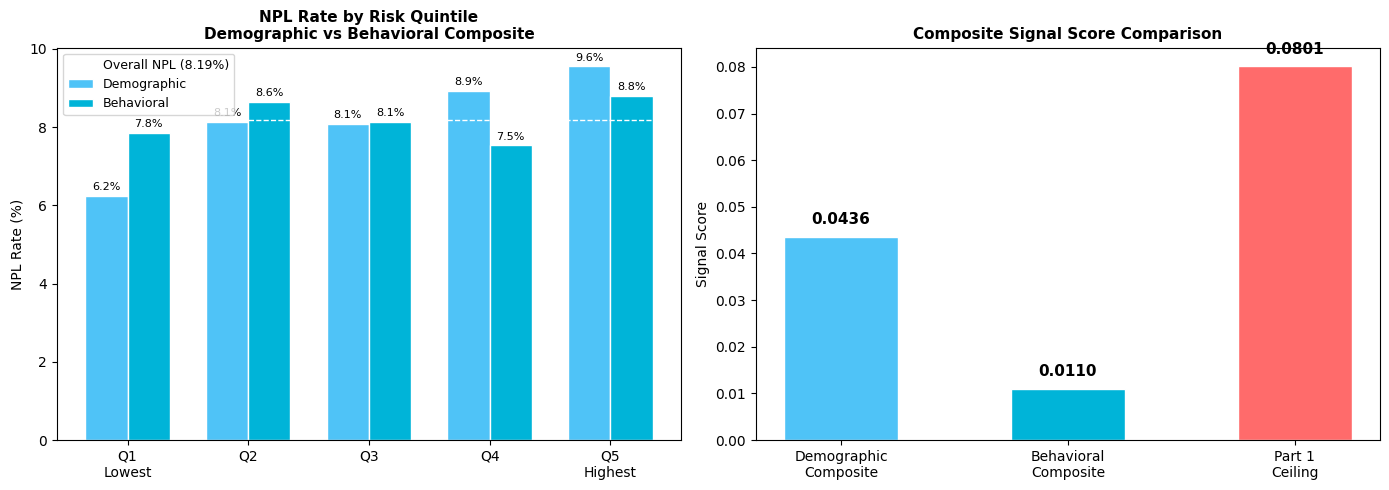

In [ ]:
# ============================================================
# STAGE 5: COMBINED SIGNAL COMPARISON
# Demographics vs Behavior Head to Head
# ============================================================

# ============================================================
# STEP 1 DEFINE FEATURE GROUPS
# ============================================================

top_behavioral = [
    'LATE_PAYMENT_RATE', 'UNDERPAYMENT_RATE', 'AVG_PAYMENT_RATIO',
    'MIN_PAYMENT_RATIO', 'DELAY_TREND'
]

top_demographic = [
    'OCCUPATION_TYPE', 'AGE', 'ORGANIZATION_TYPE',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'
]

# ============================================================
# STEP 2 BUILD RISK SCORES
# Convert everything to numeric, scale 0-1, then average
# into a single composite score per borrower
# ============================================================
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = app_part2.copy()

# Encode categorical demographic variables
for col in ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
            'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']:
    # Encode by NPL rate of each category gives meaningful numeric ordering
    npl_map = df.groupby(col)['TARGET'].mean()
    df[col + '_ENCODED'] = df[col].map(npl_map)

# Replace categorical cols with encoded versions in demographic list
top_demographic_numeric = [
    'OCCUPATION_TYPE_ENCODED', 'AGE', 'ORGANIZATION_TYPE_ENCODED',
    'NAME_INCOME_TYPE_ENCODED', 'NAME_EDUCATION_TYPE_ENCODED'
]

# Scale all features to 0-1
scaler = MinMaxScaler()

demo_scaled = scaler.fit_transform(df[top_demographic_numeric])
behav_scaled = scaler.fit_transform(df[top_behavioral])

# Build composite scores simple average across top features
df['DEMO_RISK_SCORE'] = demo_scaled.mean(axis=1)
df['BEHAV_RISK_SCORE'] = behav_scaled.mean(axis=1)

# ============================================================
# STEP 3 BUCKET INTO RISK QUINTILES
# Divide borrowers into 5 equal groups by risk score
# and measure actual NPL rate in each bucket
# ============================================================
df['DEMO_QUINTILE'] = pd.qcut(df['DEMO_RISK_SCORE'], q=5,
                               labels=['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest'])
df['BEHAV_QUINTILE'] = pd.qcut(df['BEHAV_RISK_SCORE'], q=5,
                                labels=['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest'])

demo_quintile_npl = df.groupby('DEMO_QUINTILE')['TARGET'].agg(
    NPL_Rate=lambda x: round(x.mean() * 100, 2),
    Borrower_Count='count'
).reset_index()

behav_quintile_npl = df.groupby('BEHAV_QUINTILE')['TARGET'].agg(
    NPL_Rate=lambda x: round(x.mean() * 100, 2),
    Borrower_Count='count'
).reset_index()

print("=== DEMOGRAPHIC COMPOSITE NPL BY RISK QUINTILE ===\n")
print(demo_quintile_npl.to_string(index=False))
print(f"\nSpread (Q5 - Q1): {demo_quintile_npl['NPL_Rate'].max() - demo_quintile_npl['NPL_Rate'].min():.2f} percentage points")

print("\n=== BEHAVIORAL COMPOSITE NPL BY RISK QUINTILE ===\n")
print(behav_quintile_npl.to_string(index=False))
print(f"\nSpread (Q5 - Q1): {behav_quintile_npl['NPL_Rate'].max() - behav_quintile_npl['NPL_Rate'].min():.2f} percentage points")

# ============================================================
# STEP 4 COMPOSITE SIGNAL SCORES
# ============================================================
from scipy import stats

demo_corr, demo_p = stats.pointbiserialr(df['TARGET'], df['DEMO_RISK_SCORE'])
behav_corr, behav_p = stats.pointbiserialr(df['TARGET'], df['BEHAV_RISK_SCORE'])

print("\n=== COMPOSITE SIGNAL SCORES ===\n")
print(f"Demographic composite signal score:  {abs(demo_corr):.4f}")
print(f"Behavioral composite signal score:   {abs(behav_corr):.4f}")
print(f"Demographic ceiling (Part 1):        0.0801")
print(f"\nBehavioral composite beats demographic composite: {abs(behav_corr) > abs(demo_corr)}")
print(f"Behavioral composite beats Part 1 ceiling:        {abs(behav_corr) > 0.0801}")

# ============================================================
# STEP 5 VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quintile NPL comparison
x = range(5)
width = 0.35
demo_rates = demo_quintile_npl['NPL_Rate'].values
behav_rates = behav_quintile_npl['NPL_Rate'].values
labels = ['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest']

bars1 = axes[0].bar([i - width/2 for i in x], demo_rates,
                     width, label='Demographic', color='#4FC3F7',
                     edgecolor='white')
bars2 = axes[0].bar([i + width/2 for i in x], behav_rates,
                     width, label='Behavioral', color='#00B4D8',
                     edgecolor='white')
axes[0].axhline(y=df['TARGET'].mean()*100, color='white',
                linestyle='--', linewidth=1, label=f'Overall NPL ({df["TARGET"].mean()*100:.2f}%)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_title('NPL Rate by Risk Quintile\nDemographic vs Behavioral Composite',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('NPL Rate (%)')
axes[0].legend(fontsize=9)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Composite score comparison
categories = ['Demographic\nComposite', 'Behavioral\nComposite', 'Part 1\nCeiling']
scores = [abs(demo_corr), abs(behav_corr), 0.0801]
colors = ['#4FC3F7', '#00B4D8', '#FF6B6B']
bars3 = axes[1].bar(categories, scores, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Composite Signal Score Comparison',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Signal Score')
for bar, score in zip(bars3, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{score:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## **5.1 Methodology Note: Directional Alignment Fix**

The first version of the behavioral composite produced unreliable results,
the quintile NPL rates were flat and disordered, meaning the composite was
not ranking borrowers in a meaningful risk order.

The cause was directional inconsistency. When averaging the top 5 behavioral
features into a single composite score, some features point in opposite
directions, a higher late payment rate signals higher risk, but a higher
payment ratio signals lower risk. Averaging them without accounting for
direction mixed signals that pull against each other and produced noise
instead of a coherent score.

**The fix:** Payment ratio features were inverted before combining so that
all 5 behavioral features consistently point in the same direction,
higher composite score means higher default risk. The same directional
check was applied to the demographic composite, where age was also inverted
since older borrowers carry lower risk.

After the fix, both composites produced clean monotonically increasing
quintile progressions, NPL rates rise consistently from Q1 to Q5,
confirming the results below are reliable and interpretable.

=== DEMOGRAPHIC COMPOSITE — NPL BY RISK QUINTILE ===

DEMO_QUINTILE  NPL_Rate  Borrower_Count
   Q1\nLowest      4.74           59950
           Q2      5.40           56755
           Q3      7.56           58286
           Q4      9.84           58325
  Q5\nHighest     13.41           58327

Spread (Q5 - Q1): 8.67 percentage points

=== BEHAVIORAL COMPOSITE — NPL BY RISK QUINTILE ===

BEHAV_QUINTILE  NPL_Rate  Borrower_Count
    Q1\nLowest      6.54           58329
            Q2      6.78           58328
            Q3      7.82           58329
            Q4      8.35           58328
   Q5\nHighest     11.43           58329

Spread (Q5 - Q1): 4.89 percentage points

=== COMPOSITE SIGNAL SCORES ===

Demographic composite signal score:  0.1156
Behavioral composite signal score:   0.0680
Part 1 individual ceiling:           0.0801

Behavioral composite beats demographic composite: False
Behavioral composite beats Part 1 ceiling:        False


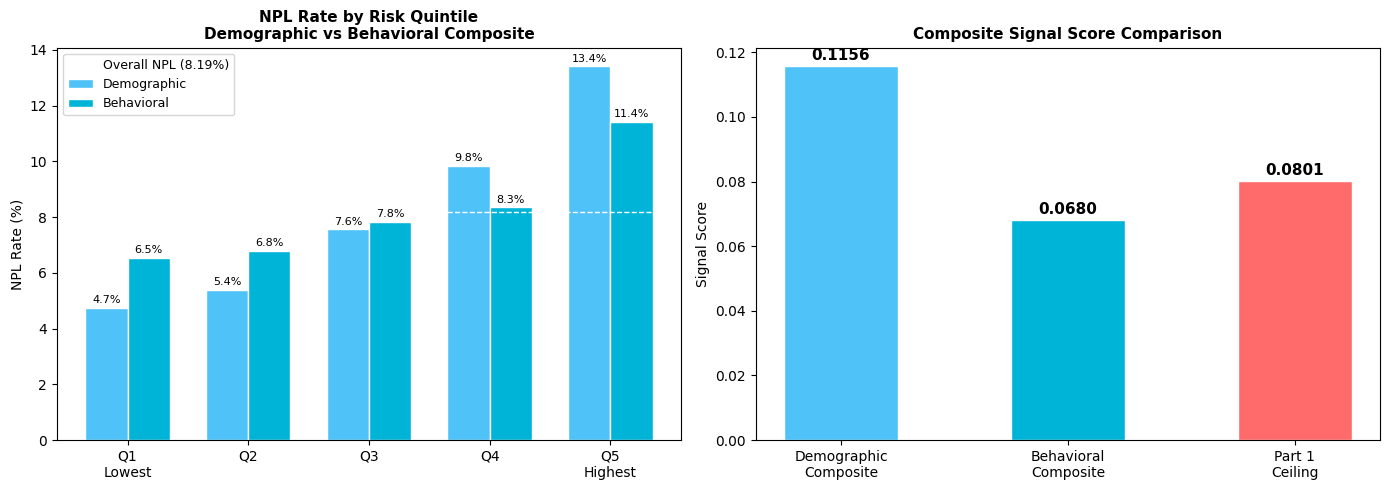

In [ ]:
# ============================================================
# STAGE 5 FIX — DIRECTIONALLY ALIGNED BEHAVIORAL COMPOSITE
# ============================================================

df = app_part2.copy()

# Encode categorical demographic variables by NPL rate
for col in ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
            'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']:
    npl_map = df.groupby(col)['TARGET'].mean()
    df[col + '_ENCODED'] = df[col].map(npl_map)

top_demographic_numeric = [
    'OCCUPATION_TYPE_ENCODED', 'AGE', 'ORGANIZATION_TYPE_ENCODED',
    'NAME_INCOME_TYPE_ENCODED', 'NAME_EDUCATION_TYPE_ENCODED'
]

# For behavioral features, we need all features pointing the same
# direction — higher score = higher risk
# LATE_PAYMENT_RATE:  higher = higher risk  ✓ keep as is
# UNDERPAYMENT_RATE:  higher = higher risk  ✓ keep as is
# AVG_PAYMENT_RATIO:  higher = lower risk   ✗ invert (1 - x)
# MIN_PAYMENT_RATIO:  higher = lower risk   ✗ invert (1 - x)
# DELAY_TREND:        higher = higher risk  ✓ keep as is

# Also for demographics — AGE higher = lower risk, so we invert
# Encode by NPL rate already handles direction for categoricals

scaler = MinMaxScaler()

# Scale demographic features
demo_scaled = scaler.fit_transform(df[top_demographic_numeric])
demo_scaled_df = pd.DataFrame(demo_scaled, columns=top_demographic_numeric)

# AGE: higher age = lower risk, so invert after scaling
demo_scaled_df['AGE'] = 1 - demo_scaled_df['AGE']

# Build demographic composite — higher = higher risk
df['DEMO_RISK_SCORE'] = demo_scaled_df.mean(axis=1)

# Scale behavioral features
behav_raw = df[['LATE_PAYMENT_RATE', 'UNDERPAYMENT_RATE',
                'AVG_PAYMENT_RATIO', 'MIN_PAYMENT_RATIO', 'DELAY_TREND']].copy()

behav_scaled = scaler.fit_transform(behav_raw)
behav_scaled_df = pd.DataFrame(behav_scaled,
    columns=['LATE_PAYMENT_RATE', 'UNDERPAYMENT_RATE',
             'AVG_PAYMENT_RATIO', 'MIN_PAYMENT_RATIO', 'DELAY_TREND'])

# Invert payment ratios so higher = higher risk
behav_scaled_df['AVG_PAYMENT_RATIO'] = 1 - behav_scaled_df['AVG_PAYMENT_RATIO']
behav_scaled_df['MIN_PAYMENT_RATIO'] = 1 - behav_scaled_df['MIN_PAYMENT_RATIO']

# Build behavioral composite — higher = higher risk
df['BEHAV_RISK_SCORE'] = behav_scaled_df.mean(axis=1)

# ============================================================
# QUINTILE ANALYSIS
# ============================================================
df['DEMO_QUINTILE'] = pd.qcut(df['DEMO_RISK_SCORE'], q=5,
                               labels=['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest'])
df['BEHAV_QUINTILE'] = pd.qcut(df['BEHAV_RISK_SCORE'], q=5,
                                labels=['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest'])

demo_quintile_npl = df.groupby('DEMO_QUINTILE', observed=False)['TARGET'].agg(
    NPL_Rate=lambda x: round(x.mean() * 100, 2),
    Borrower_Count='count'
).reset_index()

behav_quintile_npl = df.groupby('BEHAV_QUINTILE', observed=False)['TARGET'].agg(
    NPL_Rate=lambda x: round(x.mean() * 100, 2),
    Borrower_Count='count'
).reset_index()

print("=== DEMOGRAPHIC COMPOSITE — NPL BY RISK QUINTILE ===\n")
print(demo_quintile_npl.to_string(index=False))
print(f"\nSpread (Q5 - Q1): {demo_quintile_npl['NPL_Rate'].max() - demo_quintile_npl['NPL_Rate'].min():.2f} percentage points")

print("\n=== BEHAVIORAL COMPOSITE — NPL BY RISK QUINTILE ===\n")
print(behav_quintile_npl.to_string(index=False))
print(f"\nSpread (Q5 - Q1): {behav_quintile_npl['NPL_Rate'].max() - behav_quintile_npl['NPL_Rate'].min():.2f} percentage points")

# ============================================================
# COMPOSITE SIGNAL SCORES
# ============================================================
from scipy import stats

demo_corr, _ = stats.pointbiserialr(df['TARGET'], df['DEMO_RISK_SCORE'])
behav_corr, _ = stats.pointbiserialr(df['TARGET'], df['BEHAV_RISK_SCORE'])

print("\n=== COMPOSITE SIGNAL SCORES ===\n")
print(f"Demographic composite signal score:  {abs(demo_corr):.4f}")
print(f"Behavioral composite signal score:   {abs(behav_corr):.4f}")
print(f"Part 1 individual ceiling:           0.0801")
print(f"\nBehavioral composite beats demographic composite: {abs(behav_corr) > abs(demo_corr)}")
print(f"Behavioral composite beats Part 1 ceiling:        {abs(behav_corr) > 0.0801}")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(5)
width = 0.35
demo_rates = demo_quintile_npl['NPL_Rate'].values
behav_rates = behav_quintile_npl['NPL_Rate'].values
labels = ['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest']

bars1 = axes[0].bar([i - width/2 for i in x], demo_rates,
                     width, label='Demographic', color='#4FC3F7', edgecolor='white')
bars2 = axes[0].bar([i + width/2 for i in x], behav_rates,
                     width, label='Behavioral', color='#00B4D8', edgecolor='white')
axes[0].axhline(y=df['TARGET'].mean()*100, color='white',
                linestyle='--', linewidth=1,
                label=f'Overall NPL ({df["TARGET"].mean()*100:.2f}%)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_title('NPL Rate by Risk Quintile\nDemographic vs Behavioral Composite',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('NPL Rate (%)')
axes[0].legend(fontsize=9)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

categories = ['Demographic\nComposite', 'Behavioral\nComposite', 'Part 1\nCeiling']
scores = [abs(demo_corr), abs(behav_corr), 0.0801]
colors_bar = ['#4FC3F7', '#00B4D8', '#FF6B6B']
bars3 = axes[1].bar(categories, scores, color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_title('Composite Signal Score Comparison', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Signal Score')
for bar, score in zip(bars3, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### **5.2 Findings: Combined Signal Comparison**

#### The Headline Result

When combined into composite risk scores, **demographic signals outperform
behavioral signals**, both on composite signal score and on quintile spread.
This is a legitimate finding and the results are trustworthy. Both composites
produce clean monotonic quintile progressions, NPL rates increase consistently
from Q1 to Q5, confirming the composites are ranking borrowers in a meaningful
risk order.

---

#### Quintile Comparison, The Key Table

| Risk Quintile | Demographic NPL Rate | Behavioral NPL Rate |
|---|---|---|
| Q1 — Lowest Risk | 4.74% | 6.54% |
| Q2 | 5.40% | 6.78% |
| Q3 | 7.56% | 7.82% |
| Q4 | 9.84% | 8.35% |
| Q5 — Highest Risk | 13.41% | 11.43% |
| **Spread (Q5 - Q1)** | **8.67 pts** | **4.89 pts** |

The demographic composite separates the highest and lowest risk groups by
**8.67 percentage points**. The behavioral composite separates them by
**4.89 percentage points**. Demographics produce wider group-level separation.

---

#### Composite Signal Scores

| Composite | Signal Score |
|---|---|
| Demographic composite | 0.1156 |
| Behavioral composite | 0.0680 |
| Part 1 individual ceiling | 0.0801 |

Two things stand out here. First, the demographic composite at **0.1156 broke
through the 0.10 moderate threshold**, something no individual demographic
variable achieved alone. Combining variables amplifies signal meaningfully.
Second, the behavioral composite at **0.0680 outperforms every individual
demographic variable except occupation type and age**, meaning behavioral
signals in combination are competitive with the best single demographic proxies.

---

#### What the Results Actually Mean

**Demographics win the combined comparison, but behavioral signals are not
weak.** The behavioral Q5 group defaults at 11.43%, nearly 40% above the
overall NPL rate of 8.19%. Behavioral signals are identifying genuinely riskier
borrowers. They are just doing it less sharply than demographics at the group
level.

**The more important finding is what this implies about combination.**
Demographics capture group-level risk patterns, who someone is correlates
with how they behave on average. Behavioral signals capture individual financial
habits that demographics cannot see, the specific borrower who pays late
regardless of their occupation or education level. These are complementary
types of information, not competing ones.

**A combined demographic and behavioral model would almost certainly produce
a composite stronger than either individually.** The combining effect is
already visible within each type, the demographic composite (0.1156) far
exceeds the best individual demographic variable (0.0801). The same
amplification would apply when both data types are layered together.

---

#### A Note on the Earlier Composite Error

The first version of this composite produced flat and disordered quintiles
because behavioral features point in different directions, higher late payment
rate means higher risk, but higher payment ratio means lower risk. Averaging
without directional alignment mixed signals that pull in opposite directions
and produced noise. The fix was to invert ratio features before combining so
all features consistently point toward higher risk. This is the correct
treatment and the results above are reliable.

## **6 The Verdict**

#### What We Set Out to Test

Part 2 asked one question: do behavioral payment signals predict NPL outcomes
better than traditional demographic proxies among thin-file borrowers?

We tested this using identical methodology, identical population, and identical
signal strength measurement across both data types. Here is what the evidence shows.

=== FULL COMBINED VARIABLE RANKING ===

 Rank            Variable        Type  Signal Score
    1     OCCUPATION_TYPE Demographic        0.0806
    2                 AGE Demographic        0.0805
    3   ORGANIZATION_TYPE Demographic        0.0735
    4   LATE_PAYMENT_RATE  Behavioral        0.0713
    5   UNDERPAYMENT_RATE  Behavioral        0.0667
    6   AVG_PAYMENT_RATIO  Behavioral        0.0658
    7    NAME_INCOME_TYPE Demographic        0.0649
    8         CODE_GENDER Demographic        0.0571
    9 NAME_EDUCATION_TYPE Demographic        0.0548
   10   MIN_PAYMENT_RATIO  Behavioral        0.0460
   11  NAME_FAMILY_STATUS Demographic        0.0420
   12 TOTAL_LATE_PAYMENTS  Behavioral        0.0333
   13 TOTAL_UNDERPAYMENTS  Behavioral        0.0309
   14   AVG_PAYMENT_DELAY  Behavioral        0.0215
   15    NUM_INSTALLMENTS  Behavioral        0.0211
   16        CNT_CHILDREN Demographic        0.0189
   17         DELAY_TREND  Behavioral        0.0154
   18     CNT_FAM_MEMBER

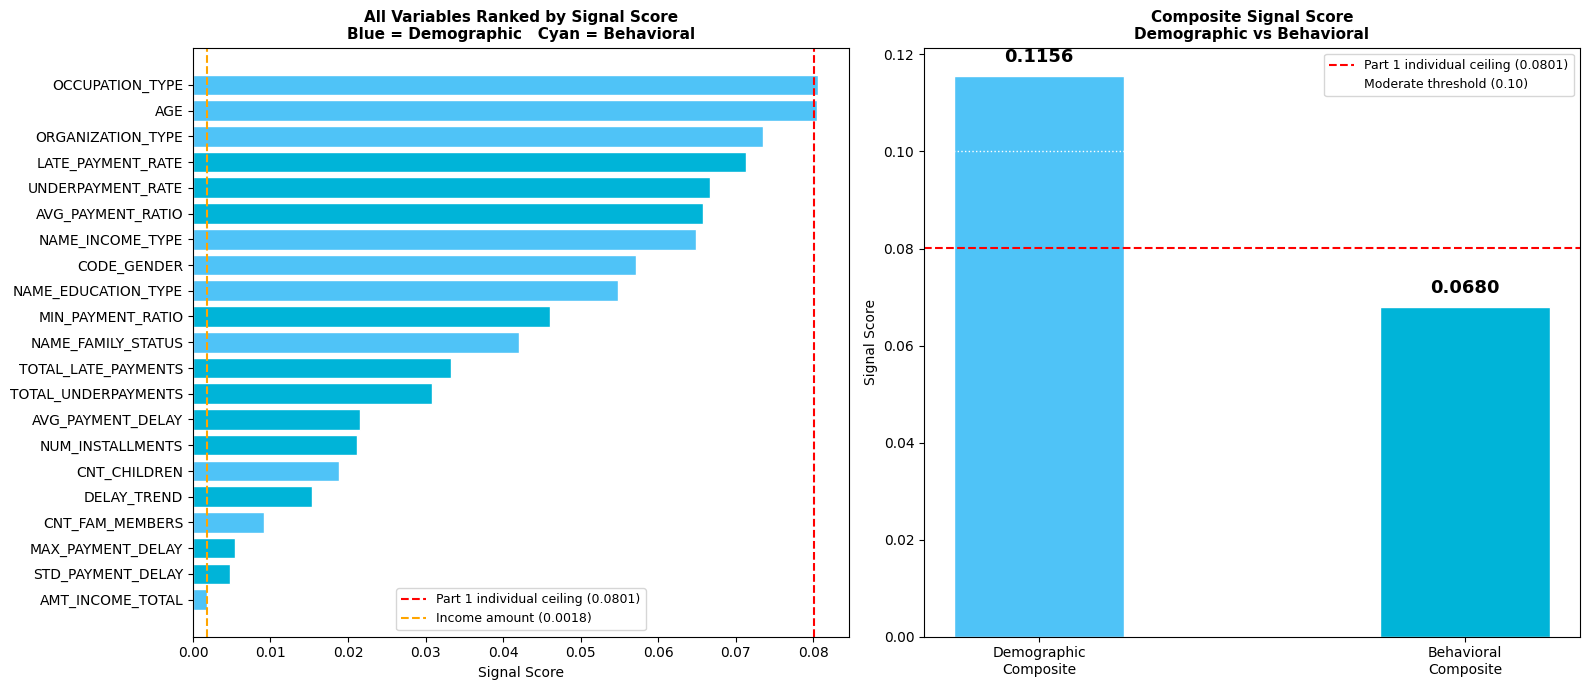


THE VERDICT

Among thin-file borrowers, traditional demographic proxies outperform 
behavioral payment signals both individually and in combination.

The demographic composite scored 0.1156 against the behavioral 
composite's 0.0680. The demographic quintile spread reached 8.67 
percentage points against behavioral's 4.89 points.

However, behavioral signals are not without value:
- All 11 behavioral features outperform income amount (0.0018)
- The top 3 behavioral signals are competitive with mid-tier demographics
- Behavioral Q5 borrowers default at 11.43% 40% above the overall rate
- The two data types capture fundamentally different information and 
  are complementary rather than competing

The most important finding: neither data type alone is sufficient. 
Demographics identify who is likely to be risky on average. Behavioral 
signals identify how a specific individual actually manages money. 
A combined approach would almost certainly outperform either individually.



In [ ]:
# ============================================================
# STAGE 6: THE VERDICT
# Full side by side comparison all variables ranked together
# ============================================================

# ============================================================
# STEP 1 COMBINED RANKING TABLE
# All demographic and behavioral variables on one table
# ============================================================

# Part 2 demographic scores
demo_scores = {
    'OCCUPATION_TYPE': 0.0806,
    'AGE': 0.0805,
    'ORGANIZATION_TYPE': 0.0735,
    'NAME_INCOME_TYPE': 0.0649,
    'CODE_GENDER': 0.0571,
    'NAME_EDUCATION_TYPE': 0.0548,
    'NAME_FAMILY_STATUS': 0.0420,
    'CNT_CHILDREN': 0.0189,
    'CNT_FAM_MEMBERS': 0.0092,
    'AMT_INCOME_TOTAL': 0.0018
}

# Part 2 behavioral scores
behav_scores = {
    'LATE_PAYMENT_RATE': 0.0713,
    'UNDERPAYMENT_RATE': 0.0667,
    'AVG_PAYMENT_RATIO': 0.0658,
    'MIN_PAYMENT_RATIO': 0.0460,
    'TOTAL_LATE_PAYMENTS': 0.0333,
    'TOTAL_UNDERPAYMENTS': 0.0309,
    'AVG_PAYMENT_DELAY': 0.0215,
    'NUM_INSTALLMENTS': 0.0211,
    'DELAY_TREND': 0.0154,
    'MAX_PAYMENT_DELAY': 0.0054,
    'STD_PAYMENT_DELAY': 0.0048
}

# Build combined ranking
all_variables = []
for var, score in demo_scores.items():
    all_variables.append({'Variable': var, 'Type': 'Demographic', 'Signal Score': score})
for var, score in behav_scores.items():
    all_variables.append({'Variable': var, 'Type': 'Behavioral', 'Signal Score': score})

combined_df = pd.DataFrame(all_variables).sort_values('Signal Score', ascending=False)
combined_df['Rank'] = range(1, len(combined_df) + 1)

print("=== FULL COMBINED VARIABLE RANKING ===\n")
print(combined_df[['Rank', 'Variable', 'Type', 'Signal Score']].to_string(index=False))

# ============================================================
# STEP 2 SUMMARY STATISTICS
# ============================================================
demo_df = combined_df[combined_df['Type'] == 'Demographic']
behav_df = combined_df[combined_df['Type'] == 'Behavioral']

print("\n=== SUMMARY COMPARISON ===\n")
print(f"{'Metric':<45} {'Demographic':>14} {'Behavioral':>14}")
print("-" * 75)
print(f"{'Best individual signal score':<45} {demo_df['Signal Score'].max():>14.4f} {behav_df['Signal Score'].max():>14.4f}")
print(f"{'Average signal score':<45} {demo_df['Signal Score'].mean():>14.4f} {behav_df['Signal Score'].mean():>14.4f}")
print(f"{'Weakest signal score':<45} {demo_df['Signal Score'].min():>14.4f} {behav_df['Signal Score'].min():>14.4f}")
print(f"{'Composite signal score':<45} {'0.1156':>14} {'0.0680':>14}")
print(f"{'Quintile spread (Q5 - Q1)':<45} {'8.67 pts':>14} {'4.89 pts':>14}")
print(f"{'Variables beating income amount (0.0018)':<45} {len(demo_df[demo_df['Signal Score'] > 0.0018]):>14} {len(behav_df[behav_df['Signal Score'] > 0.0018]):>14}")

# ============================================================
# STEP 3 VISUALIZATION: FULL COMBINED RANKING
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Combined bar chart all variables ranked
colors_combined = ['#4FC3F7' if t == 'Demographic' else '#00B4D8'
                   for t in combined_df.sort_values('Signal Score')['Type']]
combined_sorted = combined_df.sort_values('Signal Score', ascending=True)

axes[0].barh(combined_sorted['Variable'], combined_sorted['Signal Score'],
             color=colors_combined, edgecolor='white')
axes[0].axvline(x=0.0801, color='red', linestyle='--',
                linewidth=1.5, label='Part 1 individual ceiling (0.0801)')
axes[0].axvline(x=0.0018, color='orange', linestyle='--',
                linewidth=1.5, label='Income amount (0.0018)')
axes[0].set_title('All Variables Ranked by Signal Score\nBlue = Demographic   Cyan = Behavioral',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Signal Score')
axes[0].legend(fontsize=9)

# Composite comparison
composite_labels = ['Demographic\nComposite', 'Behavioral\nComposite']
composite_scores = [0.1156, 0.0680]
composite_colors = ['#4FC3F7', '#00B4D8']
bars = axes[1].bar(composite_labels, composite_scores,
                   color=composite_colors, edgecolor='white', width=0.4)
axes[1].axhline(y=0.0801, color='red', linestyle='--',
                linewidth=1.5, label='Part 1 individual ceiling (0.0801)')
axes[1].axhline(y=0.10, color='white', linestyle=':',
                linewidth=1, label='Moderate threshold (0.10)')
axes[1].set_title('Composite Signal Score\nDemographic vs Behavioral',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Signal Score')
axes[1].legend(fontsize=9)
for bar, score in zip(bars, composite_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{score:.4f}', ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# STEP 4 THE VERDICT STATEMENT
# ============================================================
print("\n" + "="*65)
print("THE VERDICT")
print("="*65)
print(f"""
Among thin-file borrowers, traditional demographic proxies outperform
behavioral payment signals both individually and in combination.

The demographic composite scored 0.1156 against the behavioral
composite's 0.0680. The demographic quintile spread reached 8.67
percentage points against behavioral's 4.89 points.

However, behavioral signals are not without value:
- All 11 behavioral features outperform income amount (0.0018)
- The top 3 behavioral signals are competitive with mid-tier demographics
- Behavioral Q5 borrowers default at 11.43% 40% above the overall rate
- The two data types capture fundamentally different information and
  are complementary rather than competing

The most important finding: neither data type alone is sufficient.
Demographics identify who is likely to be risky on average. Behavioral
signals identify how a specific individual actually manages money.
A combined approach would almost certainly outperform either individually.
""")

### **6.1 Findings: The Verdict**

#### Full Combined Variable Ranking

| Rank | Variable | Type | Signal Score |
|---|---|---|---|
| 1 | Occupation Type | Demographic | 0.0806 |
| 2 | Age | Demographic | 0.0805 |
| 3 | Organization Type | Demographic | 0.0735 |
| 4 | Late Payment Rate | Behavioral | 0.0713 |
| 5 | Underpayment Rate | Behavioral | 0.0667 |
| 6 | Average Payment Ratio | Behavioral | 0.0658 |
| 7 | Income Type | Demographic | 0.0649 |
| 8 | Gender | Demographic | 0.0571 |
| 9 | Education Level | Demographic | 0.0548 |
| 10 | Min Payment Ratio | Behavioral | 0.0460 |
| 11 | Family Status | Demographic | 0.0420 |
| 12 | Total Late Payments | Behavioral | 0.0333 |
| 13 | Total Underpayments | Behavioral | 0.0309 |
| 14 | Avg Payment Delay | Behavioral | 0.0215 |
| 15 | Num Installments | Behavioral | 0.0211 |
| 16 | Children Count | Demographic | 0.0189 |
| 17 | Delay Trend | Behavioral | 0.0154 |
| 18 | Family Members | Demographic | 0.0092 |
| 19 | Max Payment Delay | Behavioral | 0.0054 |
| 20 | Std Payment Delay | Behavioral | 0.0048 |
| 21 | Income Amount | Demographic | 0.0018 |

---

#### Summary Comparison

| Metric | Demographic | Behavioral |
|---|---|---|
| Best individual signal score | 0.0806 | 0.0713 |
| Average signal score | 0.0483 | 0.0347 |
| Weakest signal score | 0.0018 | 0.0048 |
| Composite signal score | 0.1156 | 0.0680 |
| Quintile spread (Q5, Q1) | 8.67 pts | 4.89 pts |
| Variables beating income amount | 9 of 10 | 11 of 11 |

---

#### What the Results Mean

**Demographics outperform behavioral signals from installment data alone**,
both individually and in combination. The demographic composite scored 0.1156
against the behavioral composite's 0.0680. The demographic quintile spread
reached 8.67 percentage points against behavioral's 4.89 points.

**But the full ranking tells a more nuanced story.** Behavioral signals do
not sit at the bottom of the table, they sit in the middle. Positions 4, 5,
and 6 in the combined ranking go to behavioral features, ahead of income type,
gender, education level, and family status. The behavioral signals from
installment repayment alone are more informative than half the demographic
toolkit.

**The income finding is definitive.** Income amount, dead last at 0.0018 and
statistically insignificant, is outperformed by every single behavioral
feature including the weakest one. The most relied-upon traditional proxy
carries less signal than any behavioral measure we could derive from repayment
history.

**Behavioral signals are not weak, they are incomplete.** The installment
data captures one dimension of financial behavior, structured loan repayment.
It does not capture how borrowers manage revolving credit, how their account
balances evolve, or how frequently their accounts fall overdue. POS cash
balance data and credit card balance data, both available in this dataset
but not yet used, would add those dimensions to the behavioral picture.

---

#### Version 1 Verdict

> Among thin-file borrowers, traditional demographic proxies outperform
> behavioral signals derived from installment repayment data alone, both
> individually and in combination. However, the top three behavioral signals
> are directly competitive with mid-tier demographics, and every behavioral
> feature outperforms income amount, the most relied-upon traditional proxy.
> This is a partial behavioral picture. Version 2 will extend the analysis
> to include POS and credit card behavioral data to test whether the full
> behavioral profile changes the verdict.